# Assignment 1: Question 1
**Course:** Machine Learning  
**Student:** Navneet Das  
**Date:** 10 Aug 2026  

---

## Implementation of a Feedforward Neural Network for Classification

### Objective
> Load the chosen classification dataset and explore its structure before modelling

## Step 1: Load the Breast Cancer dataset.

In [80]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn.preprocessing import StandardScaler

In [57]:
# Loading meta dataset
dataset = datasets.load_breast_cancer()
dataset.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [58]:
# Cleaning dataset
data=pd.DataFrame(dataset["data"])
data["target"]=dataset["target"]

## Step 2: Display the first five samples.

In [59]:
data.head()

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [76]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       569 non-null    float64
 1   1       569 non-null    float64
 2   2       569 non-null    float64
 3   3       569 non-null    float64
 4   4       569 non-null    float64
 5   5       569 non-null    float64
 6   6       569 non-null    float64
 7   7       569 non-null    float64
 8   8       569 non-null    float64
 9   9       569 non-null    float64
 10  10      569 non-null    float64
 11  11      569 non-null    float64
 12  12      569 non-null    float64
 13  13      569 non-null    float64
 14  14      569 non-null    float64
 15  15      569 non-null    float64
 16  16      569 non-null    float64
 17  17      569 non-null    float64
 18  18      569 non-null    float64
 19  19      569 non-null    float64
 20  20      569 non-null    float64
 21  21      569 non-null    float64
 22  22

In [77]:
data.describe()

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


## Step 3: Display the dataset shape.

In [61]:
print(f"the shape of the given dataset is :{data.shape}")

the shape of the given dataset is :(569, 31)


## Step 4: Display the number of features.

In [62]:
# separation of data
features=data.iloc[:,:-1]
target=data["target"]

In [63]:
print(f"The number od features are {features.shape[1]}")

The number od features are 30


## Step 5: Display the number of classes.

In [71]:
print(f"in total we have {data["target"].nunique()} classes which are {data["target"].unique()} or {dataset["target_names"]}")

in total we have 2 classes which are [0 1] or ['malignant' 'benign']


## Step 6: Check for missing values.

In [75]:
data.isnull().sum()

0         0
1         0
2         0
3         0
4         0
5         0
6         0
7         0
8         0
9         0
10        0
11        0
12        0
13        0
14        0
15        0
16        0
17        0
18        0
19        0
20        0
21        0
22        0
23        0
24        0
25        0
26        0
27        0
28        0
29        0
target    0
dtype: int64

# Question 2

---

## Data Preprocessing
### Objective
> Prepare the dataset for neural network training

## Step 7: Split the dataset into training and testing sets.

In [79]:
xtrain,xtest,ytrain,ytest=train_test_split(data.iloc[:,:-1],data["target"],test_size=0.2,shuffle=True,random_state=42)
print(f"shape of xtrain :{xtrain.shape}")
print(f"shape of xtest :{xtest.shape}")
print(f"shape of ytrain :{ytrain.shape}")
print(f"shape of ytest :{ytest.shape}")

shape of xtrain :(455, 30)
shape of xtest :(114, 30)
shape of ytrain :(455,)
shape of ytest :(114,)


## Step 8: Standardize all numerical features.

In [81]:
ss = StandardScaler()
xtrain_scaled = ss.fit_transform(xtrain)
xtest_scaled = ss.transform(xtest)
xtrain_scaled

array([[-1.44075296, -0.43531947, -1.36208497, ...,  0.9320124 ,
         2.09724217,  1.88645014],
       [ 1.97409619,  1.73302577,  2.09167167, ...,  2.6989469 ,
         1.89116053,  2.49783848],
       [-1.39998202, -1.24962228, -1.34520926, ..., -0.97023893,
         0.59760192,  0.0578942 ],
       ...,
       [ 0.04880192, -0.55500086, -0.06512547, ..., -1.23903365,
        -0.70863864, -1.27145475],
       [-0.03896885,  0.10207345, -0.03137406, ...,  1.05001236,
         0.43432185,  1.21336207],
       [-0.54860557,  0.31327591, -0.60350155, ..., -0.61102866,
        -0.3345212 , -0.84628745]])

Text(0.5, 1.0, 'After')

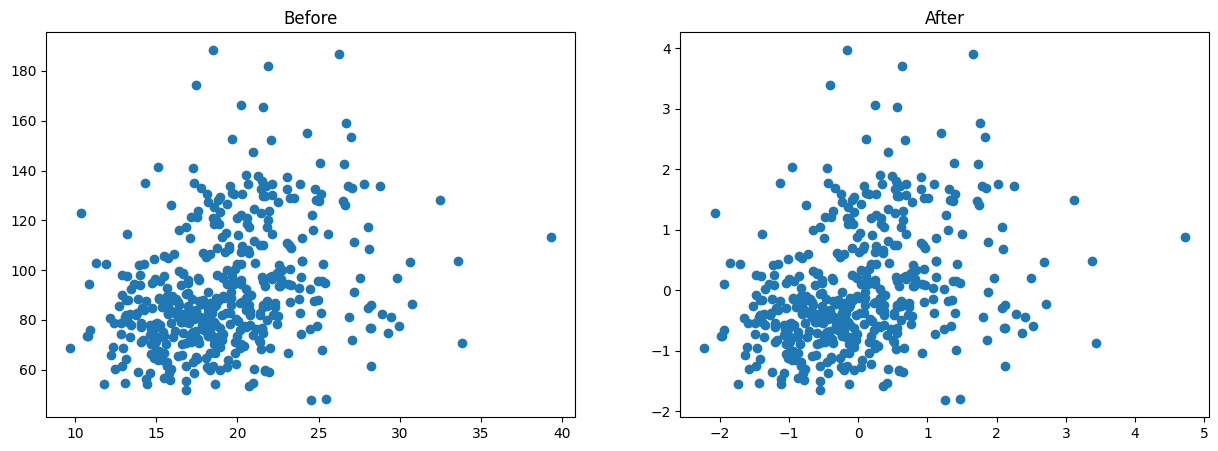

In [100]:
fig ,(ax1 , ax2) = plt.subplots(nrows=1,ncols=2, figsize=(15,5))
ax1.scatter(xtrain[1],xtrain[2])
ax1.set_title("Before")
ax2.scatter(xtrain_scaled[:,1],xtrain_scaled[:,2])
ax2.set_title("After")

## Step 9: Explain why feature scaling is important for neural networks.

* **Prevents Dominance:** _Large-scale inputs drown out small-scale inputs during early training updates._
* **Fair Learning** _Every input feature gets an equal chance to influence the network's weights._